## **Memuat Dataset**

In [1]:
# Upload file
from google.colab import files
uploaded = files.upload()

# Ekstrak file zip

import zipfile
import os

zip_file = "vehicleinsurance.zip"

extract_path = "/content/vehicleinsurance"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv("/content/vehicleinsurance/carclaims.csv")

# Menampilkan 5 data pertama

df.head()

Saving vehicleinsurance.zip to vehicleinsurance.zip
Dataset berhasil diekstrak!


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


## **Eksplorasi Data**

In [2]:
# Ukuran dataset

print("Jumlah baris dan kolom:")
print(df.shape)

Jumlah baris dan kolom:
(15420, 33)


In [3]:
# Informasi dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber          15420 non-null

In [4]:
# Cek duplikat data

print("Jumlah data duplikat:")
print(df.duplicated().sum())

Jumlah data duplikat:
0


In [5]:
# Jumlah unique setiap kolom

for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

Month : 12 unique values
WeekOfMonth : 5 unique values
DayOfWeek : 7 unique values
Make : 19 unique values
AccidentArea : 2 unique values
DayOfWeekClaimed : 8 unique values
MonthClaimed : 13 unique values
WeekOfMonthClaimed : 5 unique values
Sex : 2 unique values
MaritalStatus : 4 unique values
Age : 66 unique values
Fault : 2 unique values
PolicyType : 9 unique values
VehicleCategory : 3 unique values
VehiclePrice : 6 unique values
PolicyNumber : 15420 unique values
RepNumber : 16 unique values
Deductible : 4 unique values
DriverRating : 4 unique values
Days:Policy-Accident : 5 unique values
Days:Policy-Claim : 4 unique values
PastNumberOfClaims : 4 unique values
AgeOfVehicle : 8 unique values
AgeOfPolicyHolder : 9 unique values
PoliceReportFiled : 2 unique values
WitnessPresent : 2 unique values
AgentType : 2 unique values
NumberOfSuppliments : 4 unique values
AddressChange-Claim : 5 unique values
NumberOfCars : 5 unique values
Year : 3 unique values
BasePolicy : 3 unique values
Frau

In [6]:
# Statistik deskriptif

df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [7]:
# Statistik deskriptif kategorikal

df.describe(include='object')

,Month,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,Sex,MaritalStatus,Fault,PolicyType,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,BasePolicy,FraudFound
count,15420,15420,15420,15420,15420,15420,15420,15420,15420,15420,...,15420,15420,15420,15420,15420,15420,15420,15420,15420,15420
unique,12,7,19,2,8,13,2,4,2,9,...,8,9,2,2,2,4,5,5,3,2
top,Jan,Monday,Pontiac,Urban,Monday,Jan,Male,Married,Policy Holder,Sedan - Collision,...,7 years,31 to 35,No,No,External,none,no change,1 vehicle,Collision,No
freq,1411,2616,3837,13822,3757,1446,13000,10625,11230,5584,...,5807,5593,14992,15333,15179,7047,14324,14316,5962,14497


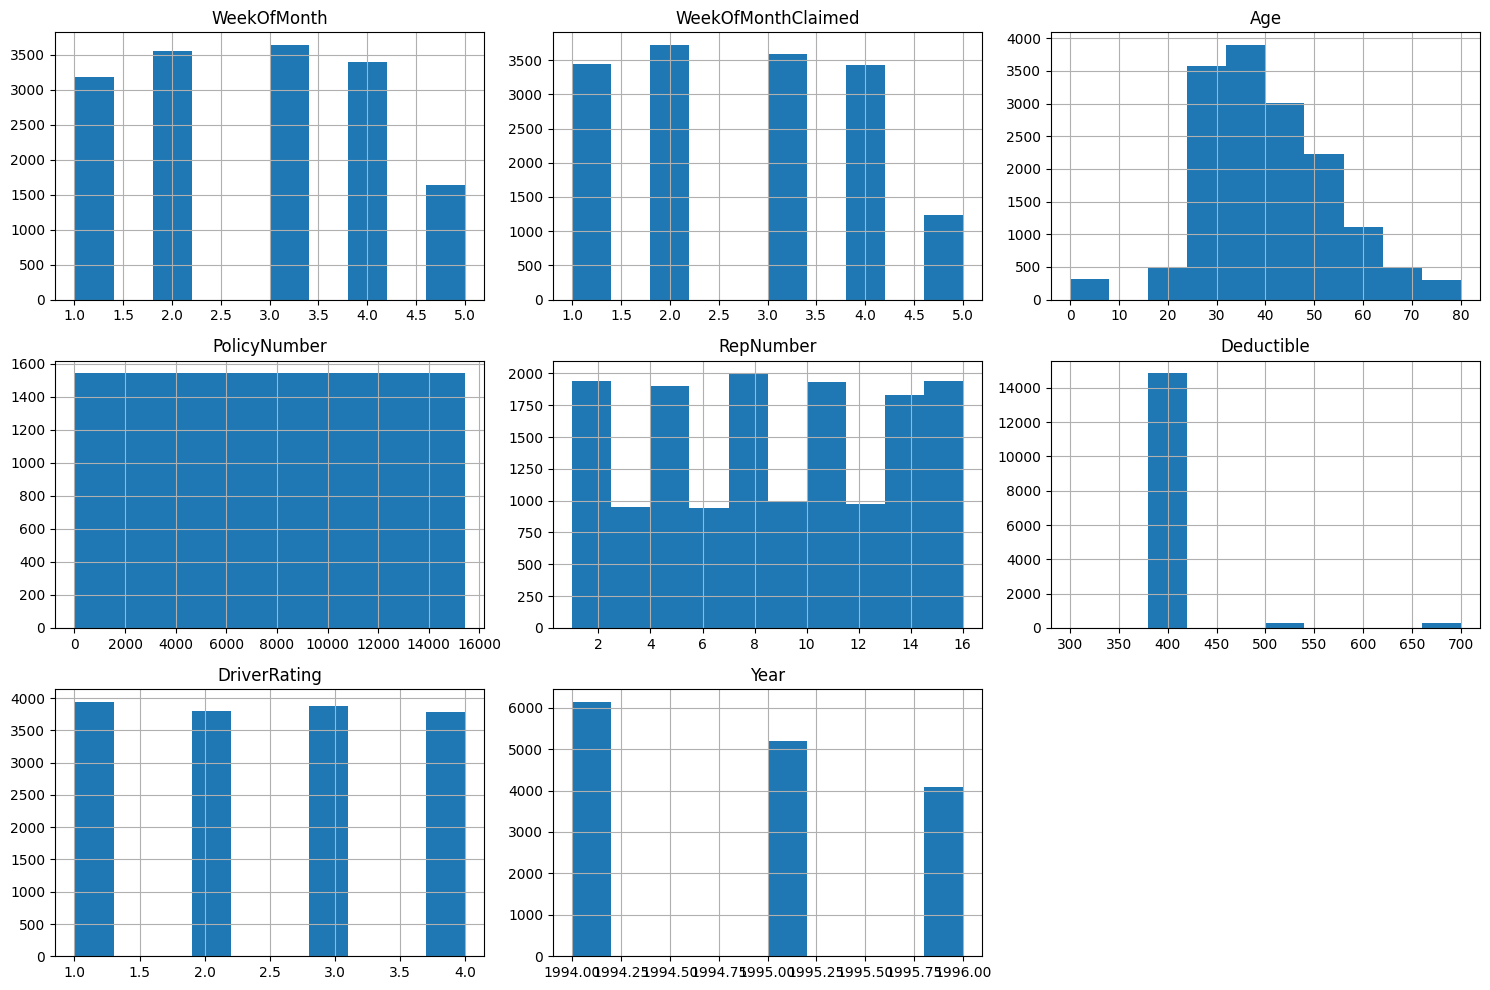

In [8]:
# Histogram variabel numerik

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_columns].hist(figsize=(15,10))

plt.tight_layout()
plt.show()

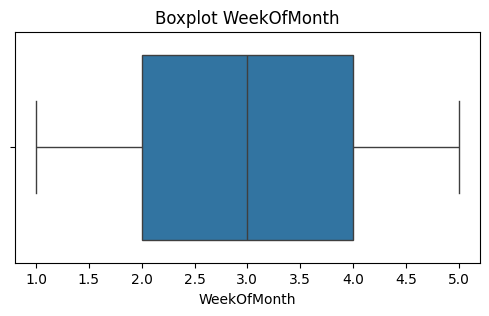

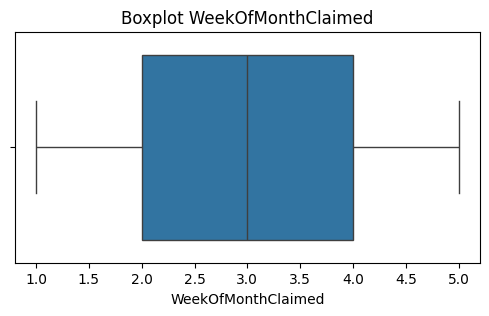

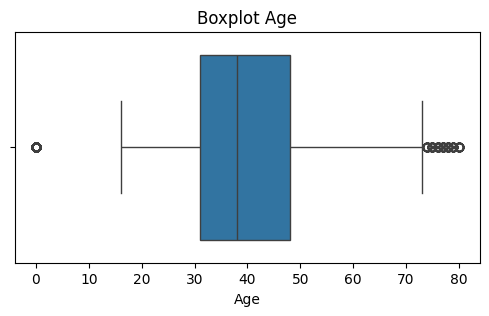

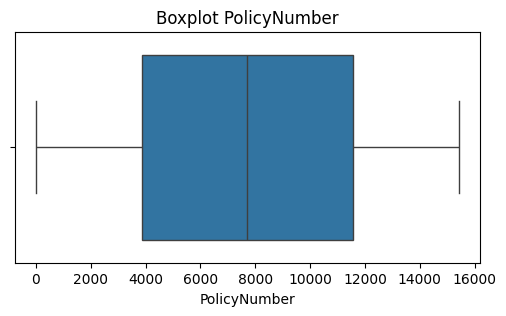

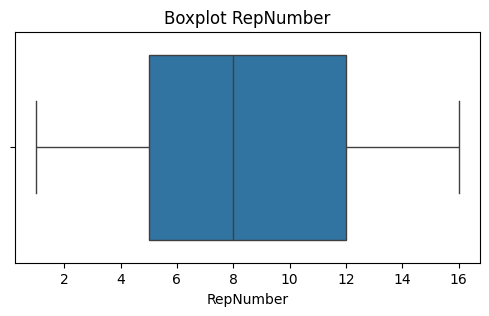

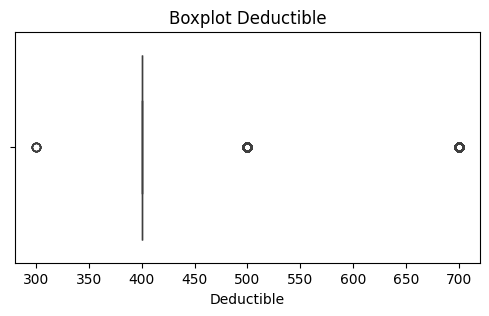

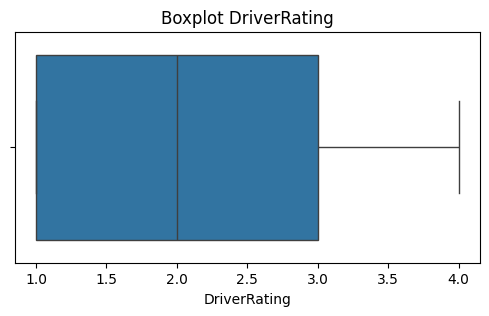

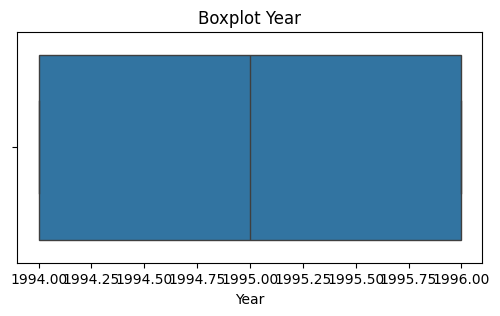

In [9]:
# Boxplot variabel numerik

for col in numeric_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot {col}')

    plt.show()

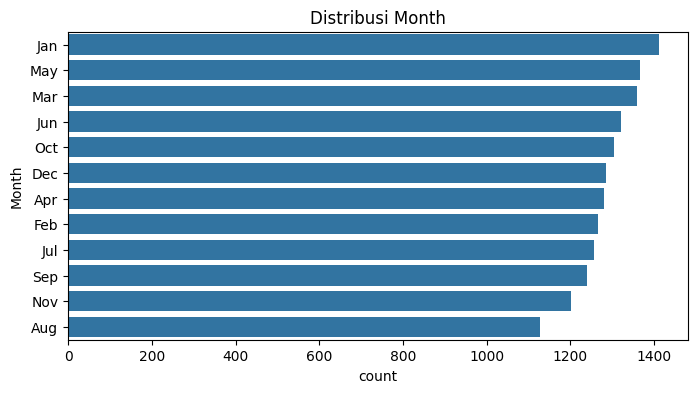

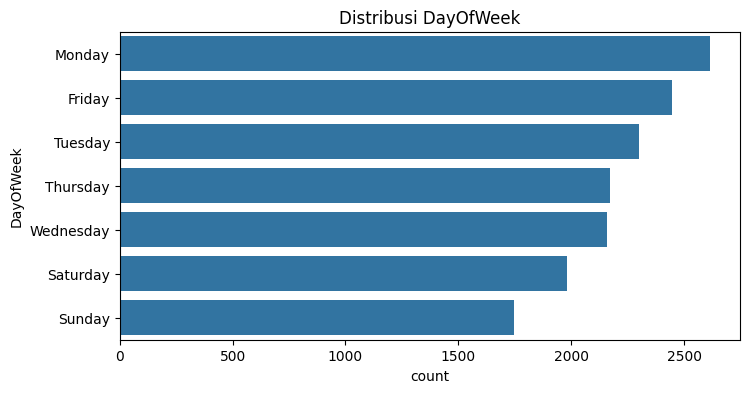

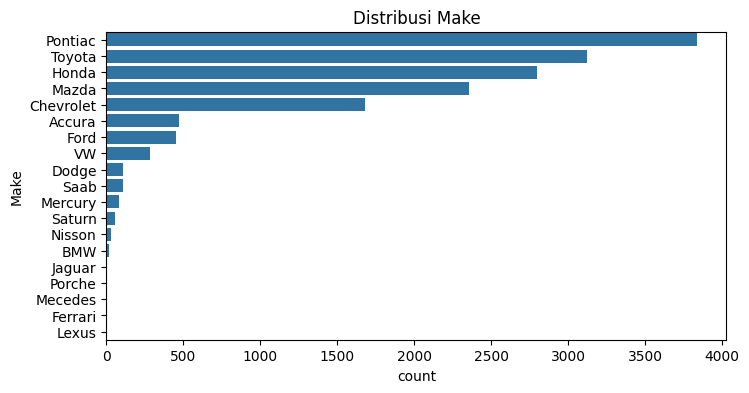

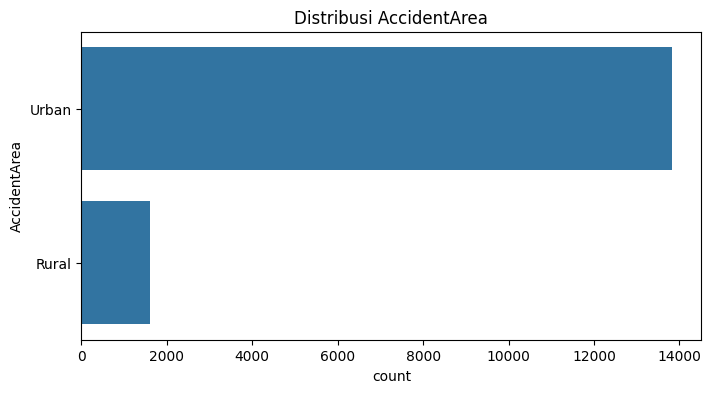

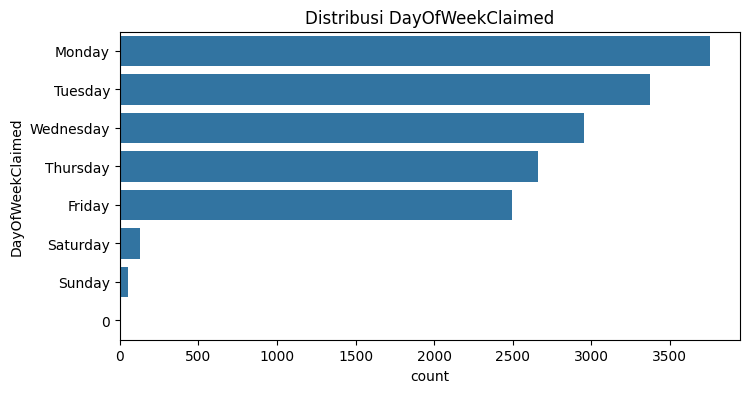

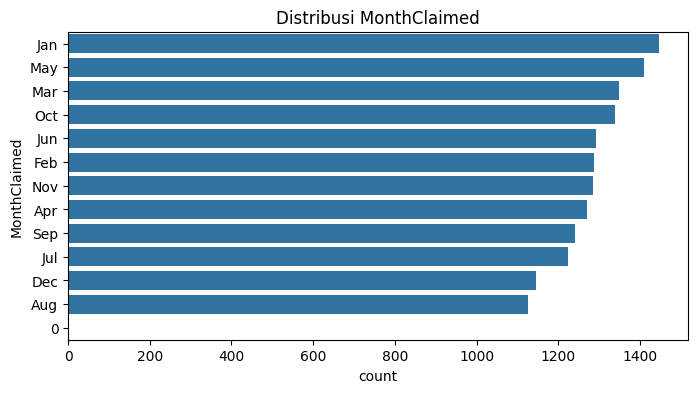

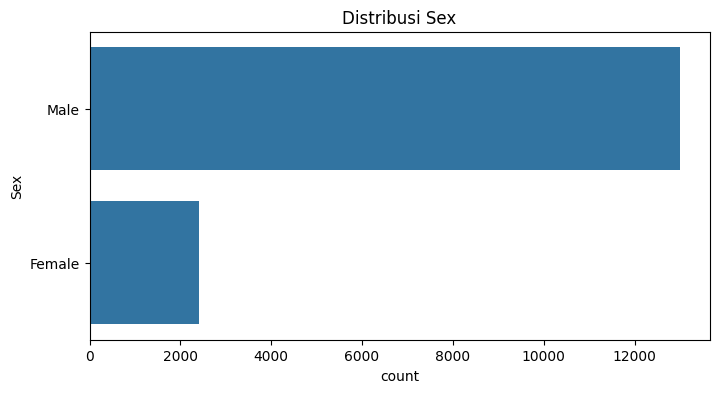

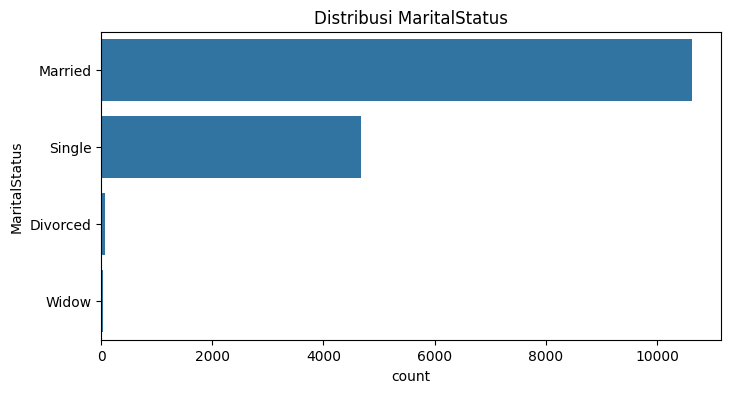

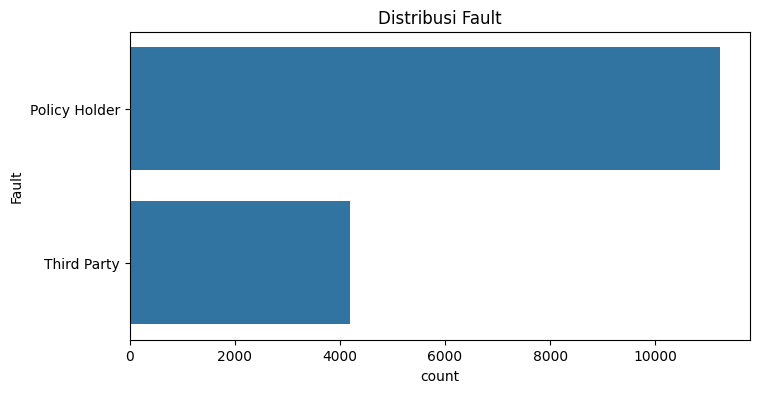

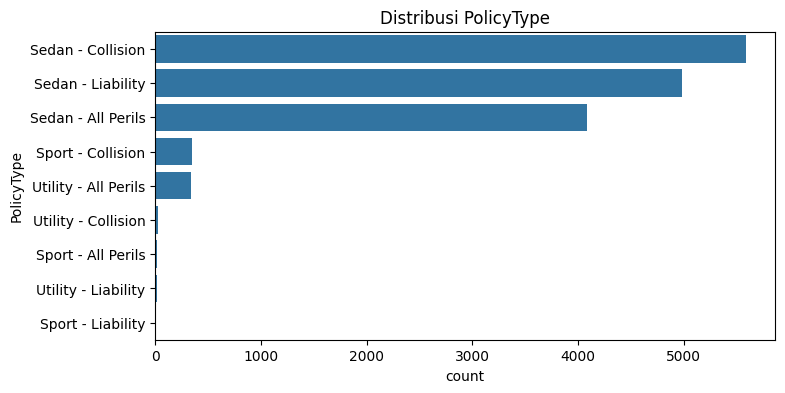

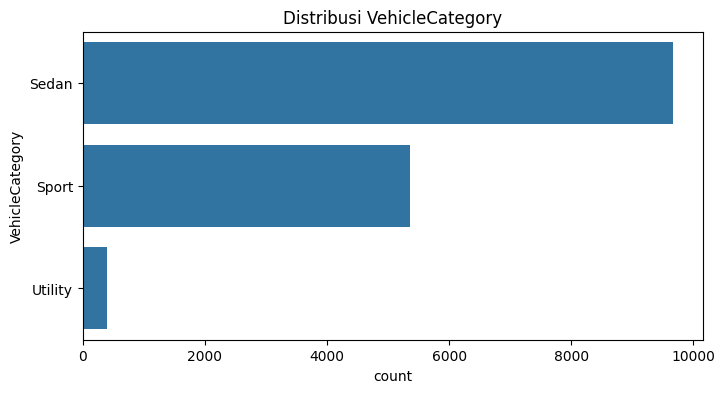

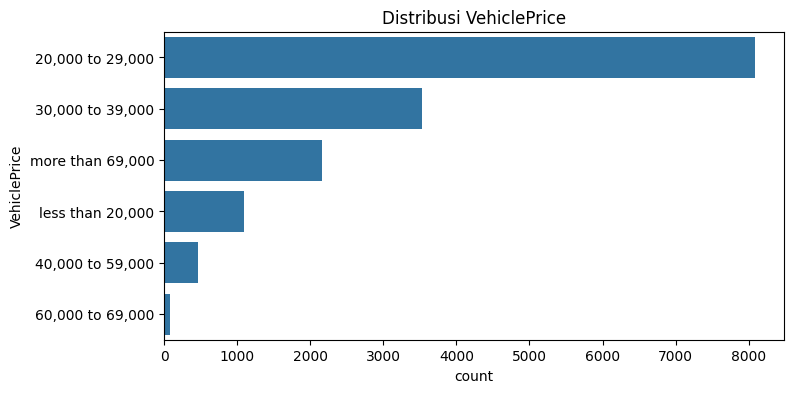

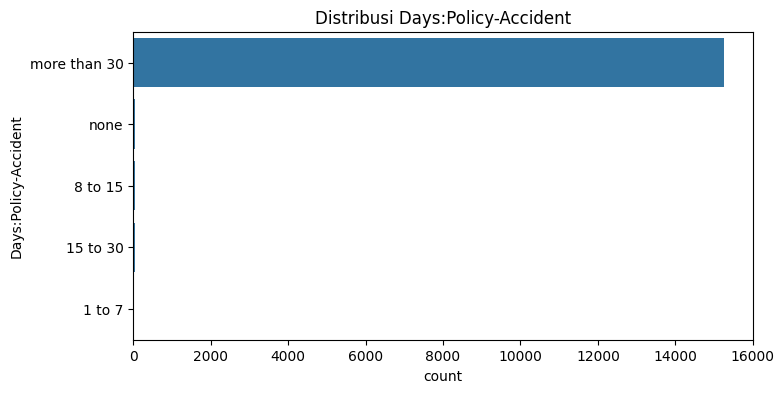

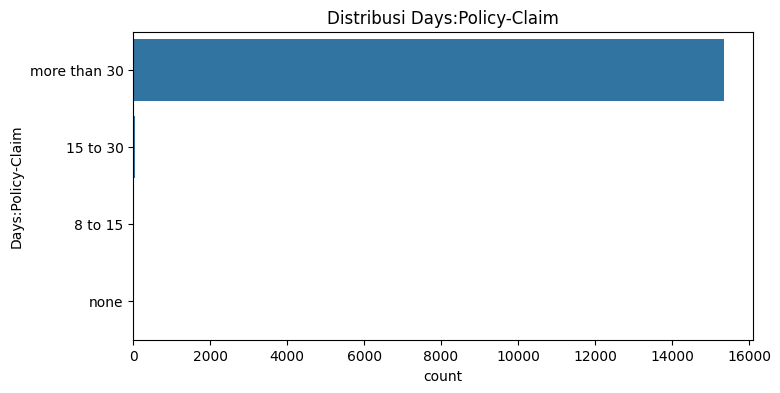

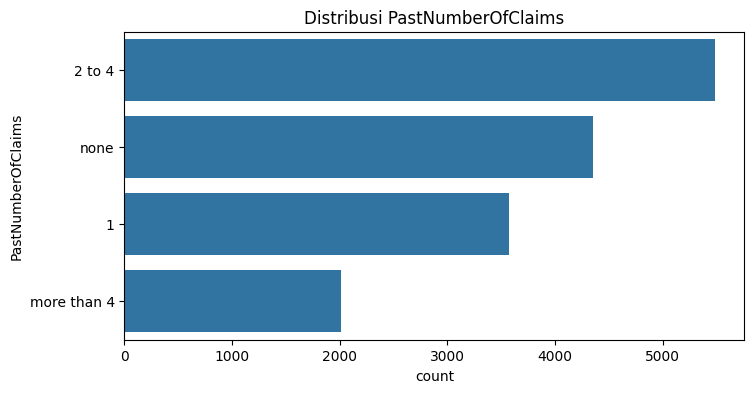

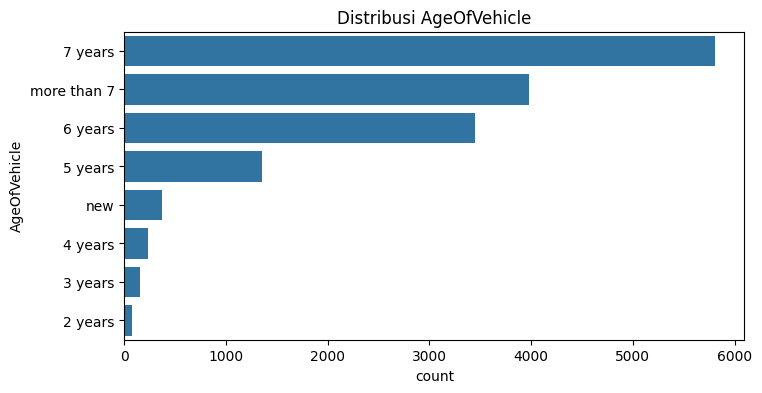

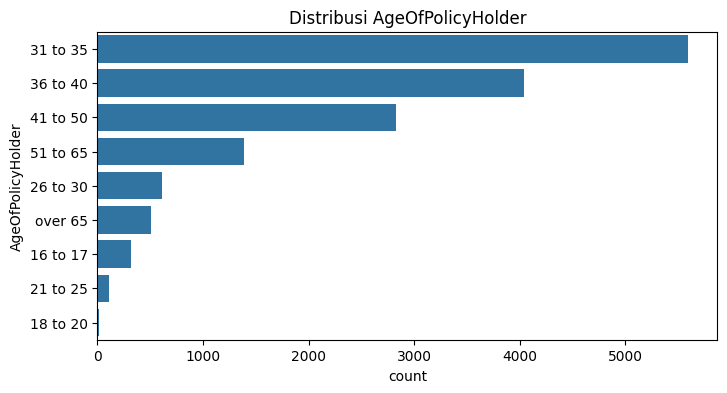

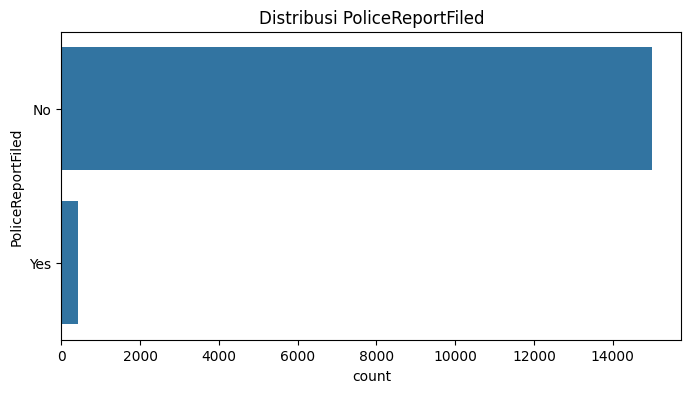

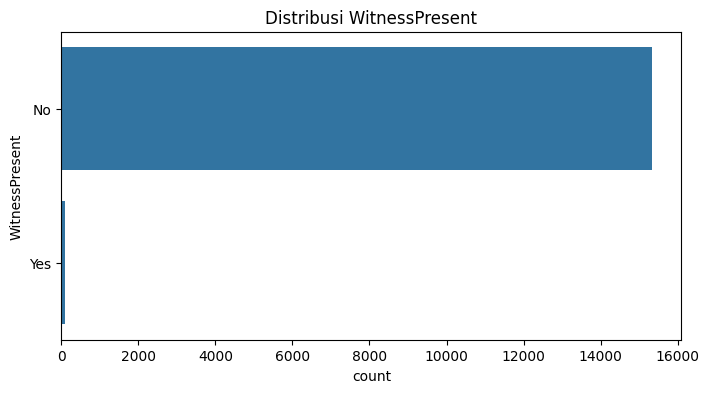

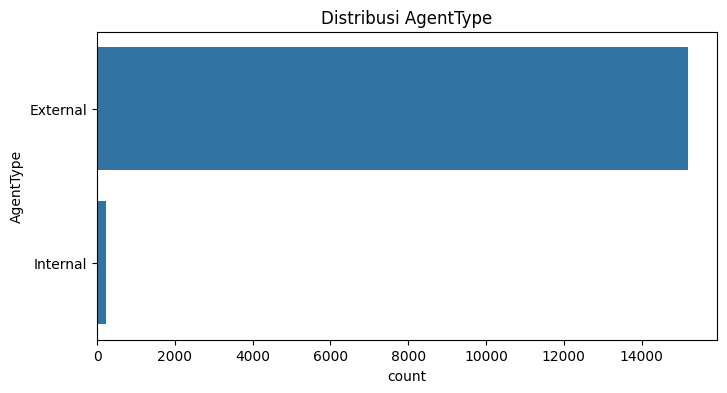

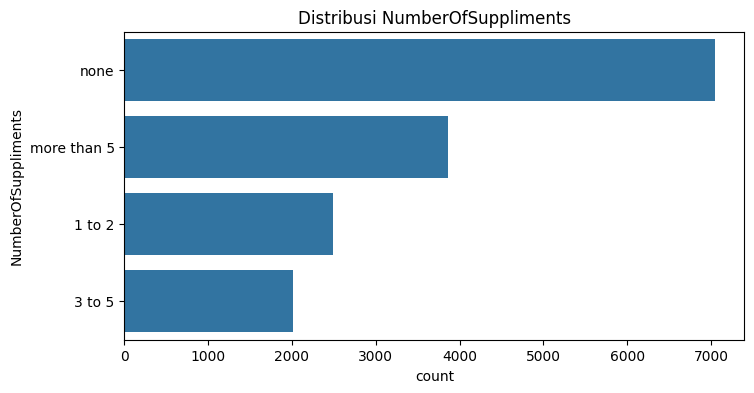

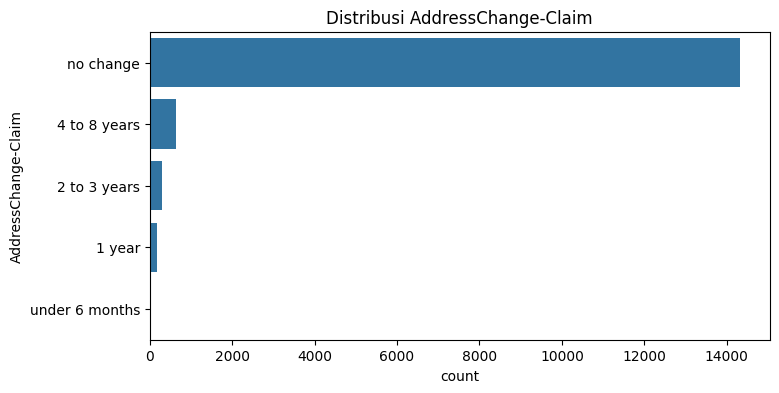

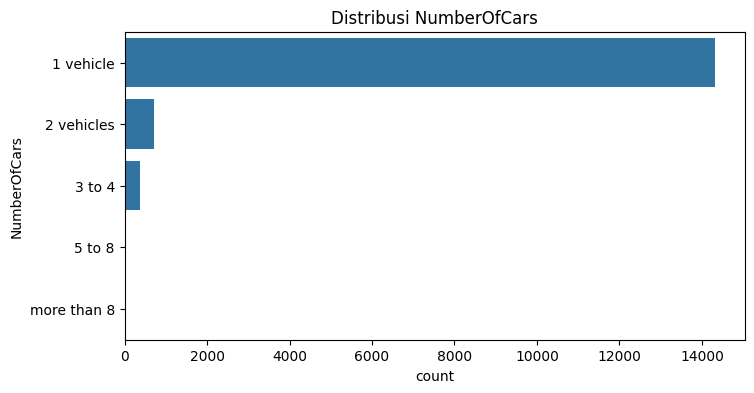

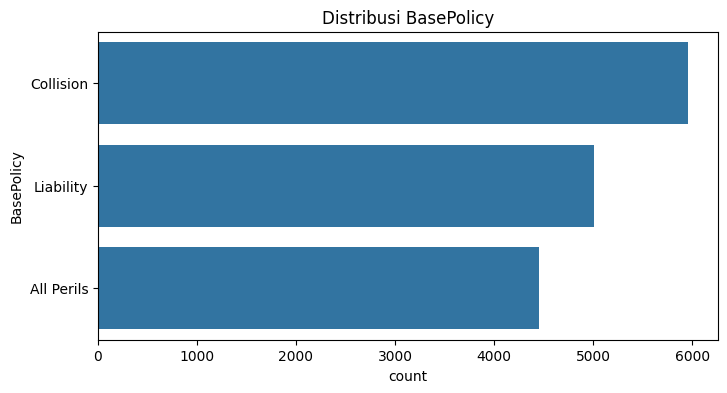

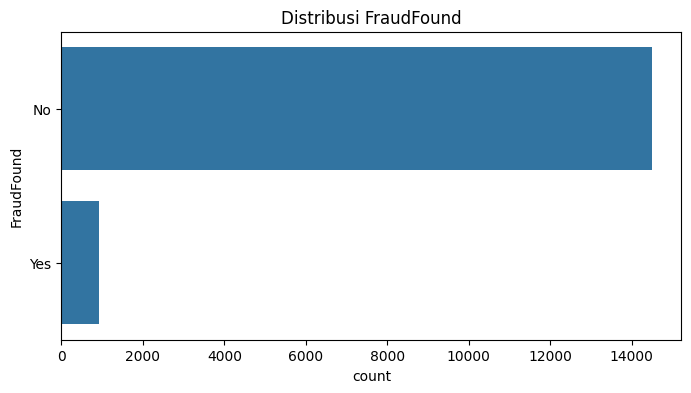

In [10]:
# Distribusi variabel kategorikal

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(y=df[col],
                  order=df[col].value_counts().index)

    plt.title(f'Distribusi {col}')

    plt.show()

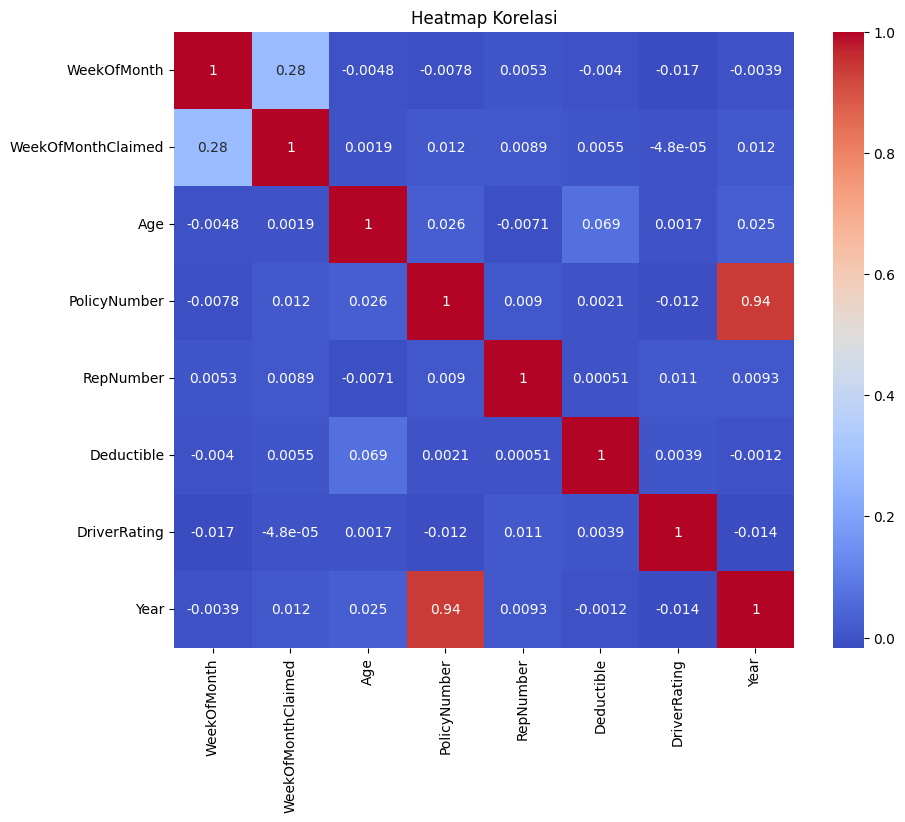

In [11]:
# Heatmap korelasi

plt.figure(figsize=(10,8))

correlation = df[numeric_columns].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Heatmap Korelasi")

plt.show()

FraudFound
No     14497
Yes      923
Name: count, dtype: int64


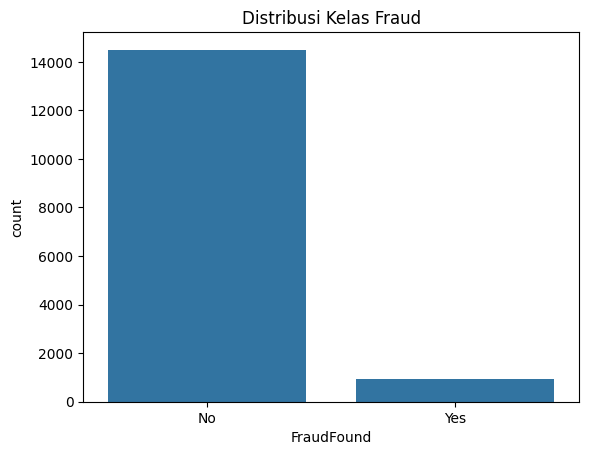

In [13]:
# Cek imbalanced data target

print(df['FraudFound'].value_counts())

sns.countplot(x='FraudFound', data=df)

plt.title("Distribusi Kelas Fraud")
plt.show()

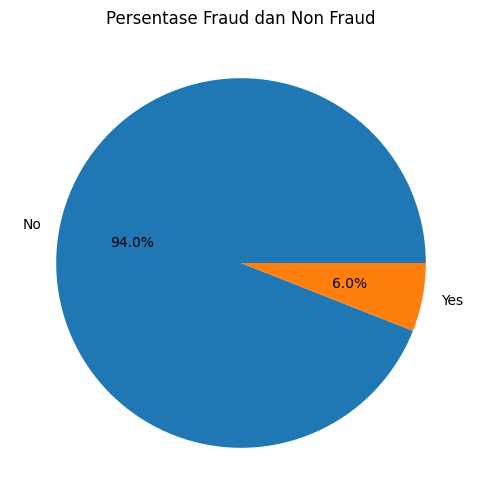

In [14]:
# Visualisasi pie chart target

df['FraudFound'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Persentase Fraud dan Non Fraud")

plt.ylabel("")

plt.show()

## ***Preprocessing***

In [15]:
# Copy dataset

data = df.copy()

In [16]:
# Drop kolom PolicyNumber

data = data.drop(columns=['PolicyNumber'])

In [17]:
# Memisahkan fitur dan target

X = data.drop('FraudFound', axis=1)

y = data['FraudFound']

In [18]:
# Encoding target

y = y.map({
    'No': 0,
    'Yes': 1
})

In [19]:
# Identifikasi tipe fitur

categorical_columns = X.select_dtypes(include='object').columns

numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns

print("Kolom kategorikal:")
print(categorical_columns)

print("\nKolom numerik:")
print(numerical_columns)

Kolom kategorikal:
Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'Days:Policy-Accident',
       'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')

Kolom numerik:
Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'RepNumber', 'Deductible',
       'DriverRating', 'Year'],
      dtype='object')


In [20]:
# One hot encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [21]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
# Standardisasi data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## **CTGAN**

In [25]:
# Import library

from ctgan import CTGAN

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Menggabungkan data train

train_data = pd.DataFrame(
    X_train,
    columns=X_encoded.columns
)

train_data['FraudFound'] = y_train.values

train_data.head()

,WeekOfMonth,WeekOfMonthClaimed,Age,RepNumber,Deductible,DriverRating,Year,Month_Aug,Month_Dec,Month_Feb,...,AddressChange-Claim_4 to 8 years,AddressChange-Claim_no change,AddressChange-Claim_under 6 months,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_5 to 8,NumberOfCars_more than 8,BasePolicy_Collision,BasePolicy_Liability,FraudFound
8294,3,3,23,6,400,4,1995,False,False,False,...,False,True,False,False,False,False,False,True,False,0
9591,3,3,34,4,400,1,1995,False,False,False,...,False,True,False,False,False,False,False,False,True,0
14227,2,2,45,6,400,4,1996,False,False,False,...,False,True,False,False,True,False,False,True,False,0
14863,3,3,40,13,400,1,1996,False,False,False,...,False,True,False,False,False,False,False,False,True,0
6994,3,5,28,13,400,1,1995,False,False,False,...,False,True,False,False,False,False,False,False,False,0


FraudFound
0    11598
1      738
Name: count, dtype: int64


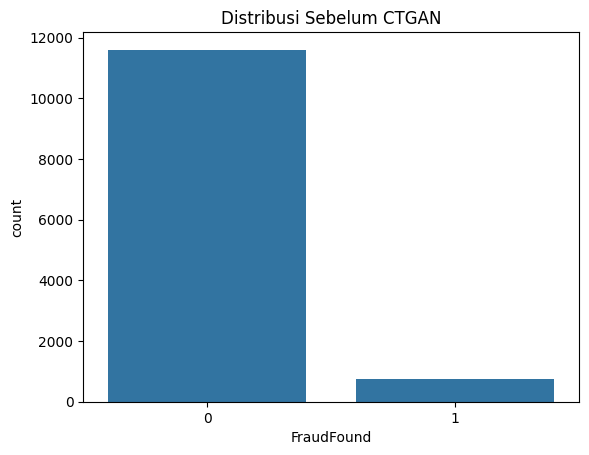

In [27]:
# Distribusi sebelum CTGAN

print(train_data['FraudFound'].value_counts())

sns.countplot(
    x='FraudFound',
    data=train_data
)

plt.title("Distribusi Sebelum CTGAN")

plt.show()

In [28]:
# Ambil data fraud

fraud_data = train_data[
    train_data['FraudFound'] == 1
]

print(fraud_data.shape)

(738, 124)


In [30]:
# Train CTGAN

ctgan = CTGAN(
    epochs=300,
    batch_size=500,
    verbose=True
)

ctgan.fit(fraud_data)

Gen. (-00.72) | Discrim. (+00.30): 100%|██████████| 300/300 [01:38<00:00,  3.05it/s]


In [31]:
# Hitung data sintetis

non_fraud_count = len(
    train_data[train_data['FraudFound'] == 0]
)

fraud_count = len(
    train_data[train_data['FraudFound'] == 1]
)

synthetic_needed = non_fraud_count - fraud_count

print(synthetic_needed)

10860


In [32]:
# Generate data sintetis

synthetic_fraud = ctgan.sample(
    synthetic_needed
)

synthetic_fraud.head()

,WeekOfMonth,WeekOfMonthClaimed,Age,RepNumber,Deductible,DriverRating,Year,Month_Aug,Month_Dec,Month_Feb,...,AddressChange-Claim_4 to 8 years,AddressChange-Claim_no change,AddressChange-Claim_under 6 months,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_5 to 8,NumberOfCars_more than 8,BasePolicy_Collision,BasePolicy_Liability,FraudFound
0,4,1,66,10,394,4,1995,True,True,True,...,True,True,True,True,True,True,True,True,True,1
1,0,1,30,9,397,4,1995,True,True,True,...,True,True,True,True,True,True,True,True,True,1
2,2,1,32,2,395,3,1995,True,True,True,...,True,True,True,True,True,True,True,True,True,1
3,4,4,35,13,397,3,1995,True,True,True,...,True,True,True,True,True,True,True,True,True,1
4,5,4,39,4,395,4,1994,True,True,True,...,True,True,True,True,True,True,True,True,True,1


In [33]:
# Label fraud

synthetic_fraud['FraudFound'] = 1

In [34]:
# Gabungkan data
augmented_data = pd.concat(
    [train_data, synthetic_fraud],
    axis=0
)

augmented_data = augmented_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(augmented_data.shape)

(23196, 124)


FraudFound
0    11598
1    11598
Name: count, dtype: int64


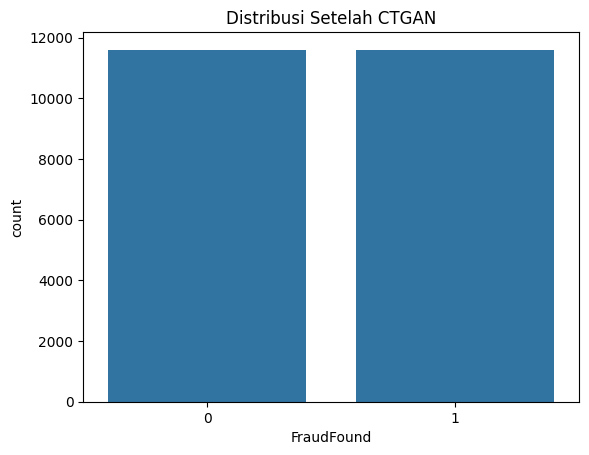

In [35]:
# Distribusi setelah CTGAN

print(
    augmented_data['FraudFound'].value_counts()
)

sns.countplot(
    x='FraudFound',
    data=augmented_data
)

plt.title("Distribusi Setelah CTGAN")

plt.show()

In [36]:
# Pisahkan fitur dan target

X_train_aug = augmented_data.drop(
    'FraudFound',
    axis=1
)

y_train_aug = augmented_data[
    'FraudFound'
]

In [37]:
# Standardisasi ulang

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_aug_scaled = scaler.fit_transform(
    X_train_aug
)

X_test_aug_scaled = scaler.transform(
    X_test
)

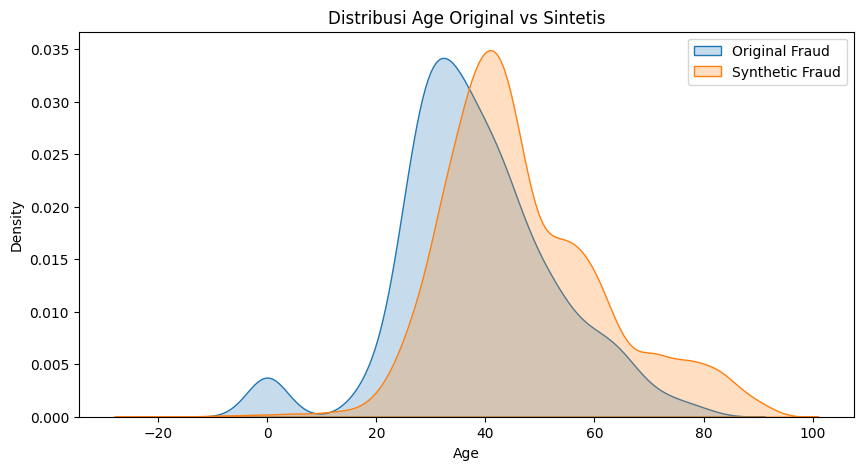

In [38]:
# Visualisasi distribusi
plt.figure(figsize=(10,5))

sns.kdeplot(
    fraud_data['Age'],
    label='Original Fraud',
    fill=True
)

sns.kdeplot(
    synthetic_fraud['Age'],
    label='Synthetic Fraud',
    fill=True
)

plt.title(
    "Distribusi Age Original vs Sintetis"
)

plt.legend()

plt.show()

## **SVM Sebelum CTGAN**

In [39]:
# SVM kernel linear (sebelum augmentasi)
from sklearn.svm import SVC

svm_linear = SVC(
    kernel='linear',
    random_state=42
)

svm_linear.fit(
    X_train_scaled,
    y_train
)

SVC(kernel='linear', random_state=42)

In [40]:
# SVM kernel polynomial (sebelum augmentasi)

svm_poly = SVC(
    kernel='poly',
    degree=3,
    random_state=42
)

svm_poly.fit(
    X_train_scaled,
    y_train
)

SVC(kernel='poly', random_state=42)

In [41]:
# SVM kernel RBF (sebelum augmentasi)

svm_rbf = SVC(
    kernel='rbf',
    random_state=42
)

svm_rbf.fit(
    X_train_scaled,
    y_train
)

SVC(random_state=42)

## **SVM Setelah CTGAN**

In [42]:
# SVM kernel linear (setelah augmentasi)

svm_linear_aug = SVC(
    kernel='linear',
    random_state=42
)

svm_linear_aug.fit(
    X_train_aug_scaled,
    y_train_aug
)

SVC(kernel='linear', random_state=42)

In [43]:
# SVM kernel polynomial (setelah augmentasi)

svm_poly_aug = SVC(
    kernel='poly',
    degree=3,
    random_state=42
)

svm_poly_aug.fit(
    X_train_aug_scaled,
    y_train_aug
)

SVC(kernel='poly', random_state=42)

In [44]:
# SVM kernel RBF (setelah augmentasi)

svm_rbf_aug = SVC(
    kernel='rbf',
    random_state=42
)

svm_rbf_aug.fit(
    X_train_aug_scaled,
    y_train_aug
)

SVC(random_state=42)

## **Pengujian Model SVM Sebelum CTGAN**

In [45]:
# SVM linear

y_train_pred_linear = svm_linear.predict(
    X_train_scaled
)

y_test_pred_linear = svm_linear.predict(
    X_test_scaled
)

In [46]:
# SVM polynomial

y_train_pred_poly = svm_poly.predict(
    X_train_scaled
)

y_test_pred_poly = svm_poly.predict(
    X_test_scaled
)

In [47]:
# SVM RBF

y_train_pred_rbf = svm_rbf.predict(
    X_train_scaled
)

y_test_pred_rbf = svm_rbf.predict(
    X_test_scaled
)

## **Pengujian Model SVM Sebelum CTGAN**

In [48]:
# SVM linear

y_train_pred_linear_aug = svm_linear_aug.predict(
    X_train_aug_scaled
)

y_test_pred_linear_aug = svm_linear_aug.predict(
    X_test_aug_scaled
)

In [49]:
# SVM polynomial

y_train_pred_poly_aug = svm_poly_aug.predict(
    X_train_aug_scaled
)

y_test_pred_poly_aug = svm_poly_aug.predict(
    X_test_aug_scaled
)

In [50]:
# SVM RBF

y_train_pred_rbf_aug = svm_rbf_aug.predict(
    X_train_aug_scaled
)

y_test_pred_rbf_aug = svm_rbf_aug.predict(
    X_test_aug_scaled
)

## **Evaluasi Model**

In [51]:
# Import library

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    classification_report
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
# Fungsi evaluasi

def evaluate_model(
    model_name,

    y_train,
    y_train_pred,

    y_test,
    y_test_pred
):

    # Train metrics

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    train_precision = precision_score(
        y_train,
        y_train_pred
    )

    train_recall = recall_score(
        y_train,
        y_train_pred
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred
    )

    # Test Metrics

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_precision = precision_score(
        y_test,
        y_test_pred
    )

    test_recall = recall_score(
        y_test,
        y_test_pred
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred
    )

    # ROC-AUC

    roc_auc = roc_auc_score(
        y_test,
        y_test_pred
    )

    # PR-AUC

    pr_auc = average_precision_score(
        y_test,
        y_test_pred
    )

    # Confusion matrix

    cm = confusion_matrix(
        y_test,
        y_test_pred
    )

    # Hasil

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    print("\nTRAIN")
    print("Accuracy :", train_accuracy)
    print("Precision:", train_precision)
    print("Recall   :", train_recall)
    print("F1-Score :", train_f1)

    print("\nTEST")
    print("Accuracy :", test_accuracy)
    print("Precision:", test_precision)
    print("Recall   :", test_recall)
    print("F1-Score :", test_f1)
    print("ROC-AUC  :", roc_auc)
    print("PR-AUC   :", pr_auc)

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_test_pred
        )
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix\n{model_name}')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    return {
        'Model': model_name,

        'Train Accuracy': train_accuracy,
        'Train Precision': train_precision,
        'Train Recall': train_recall,
        'Train F1-Score': train_f1,

        'Test Accuracy': test_accuracy,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1-Score': test_f1,

        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }

In [53]:
# List hasil

results = []


SVM Linear Before CTGAN

TRAIN
Accuracy : 0.940337224383917
Precision: 0.75
Recall   : 0.0040650406504065045
F1-Score : 0.008086253369272238

TEST
Accuracy : 0.9400129701686122
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.05998702983138781

Confusion Matrix
[[2899    0]
 [ 185    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

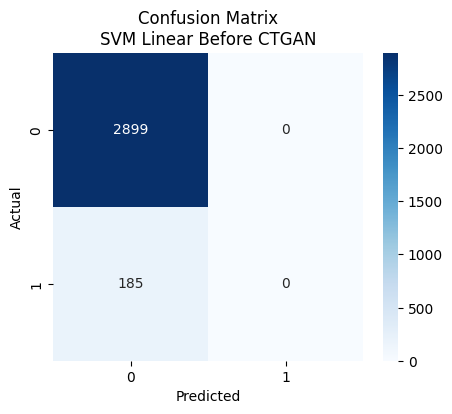

In [54]:
# SVM linear sebelum CTGAN
results.append(
    evaluate_model(
        "SVM Linear Before CTGAN",

        y_train,
        y_train_pred_linear,

        y_test,
        y_test_pred_linear
    )
)


SVM Polynomial Before CTGAN

TRAIN
Accuracy : 0.9530642023346303
Precision: 1.0
Recall   : 0.21544715447154472
F1-Score : 0.35451505016722407

TEST
Accuracy : 0.9383916990920882
Precision: 0.3076923076923077
Recall   : 0.021621621621621623
F1-Score : 0.04040404040404041
ROC-AUC  : 0.5092585514110178
PR-AUC   : 0.06534281962297527

Confusion Matrix
[[2890    9]
 [ 181    4]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.31      0.02      0.04       185

    accuracy                           0.94      3084
   macro avg       0.62      0.51      0.50      3084
weighted avg       0.90      0.94      0.91      3084



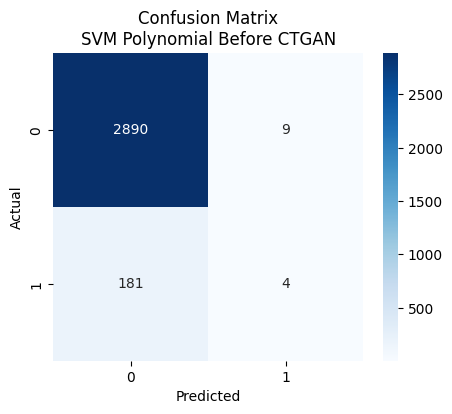

In [55]:
# SVM polynomial sebelum CTGAN
results.append(
    evaluate_model(
        "SVM Polynomial Before CTGAN",

        y_train,
        y_train_pred_poly,

        y_test,
        y_test_pred_poly
    )
)


SVM RBF Before CTGAN

TRAIN
Accuracy : 0.9421206225680934
Precision: 1.0
Recall   : 0.032520325203252036
F1-Score : 0.06299212598425197

TEST
Accuracy : 0.9400129701686122
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.05998702983138781

Confusion Matrix
[[2899    0]
 [ 185    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

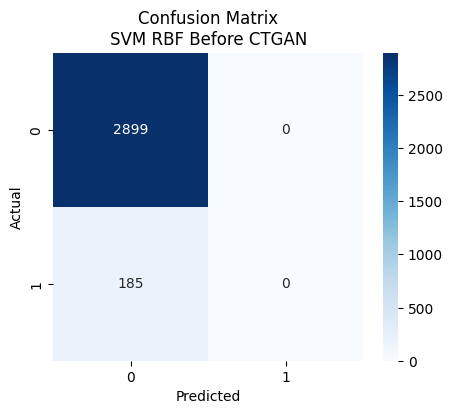

In [56]:
# SVM RBF sebelum CTGAN
results.append(
    evaluate_model(
        "SVM RBF Before CTGAN",

        y_train,
        y_train_pred_rbf,

        y_test,
        y_test_pred_rbf
    )
)


SVM Linear After CTGAN

TRAIN
Accuracy : 0.9682703914468012
Precision: 0.9999079528718704
Recall   : 0.9366270046559751
F1-Score : 0.967233549995548

TEST
Accuracy : 0.9400129701686122
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.05998702983138781

Confusion Matrix
[[2899    0]
 [ 185    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

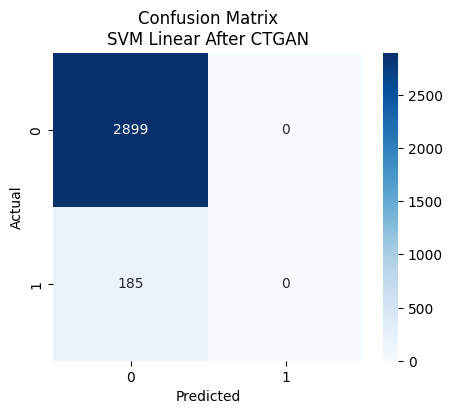

In [57]:
# SVM linear setelah CTGAN

results.append(
    evaluate_model(
        "SVM Linear After CTGAN",

        y_train_aug,
        y_train_pred_linear_aug,

        y_test,
        y_test_pred_linear_aug
    )
)


SVM Polynomial After CTGAN

TRAIN
Accuracy : 0.9695637178823935
Precision: 1.0
Recall   : 0.9391274357647871
F1-Score : 0.9686082703423744

TEST
Accuracy : 0.9400129701686122
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.05998702983138781

Confusion Matrix
[[2899    0]
 [ 185    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

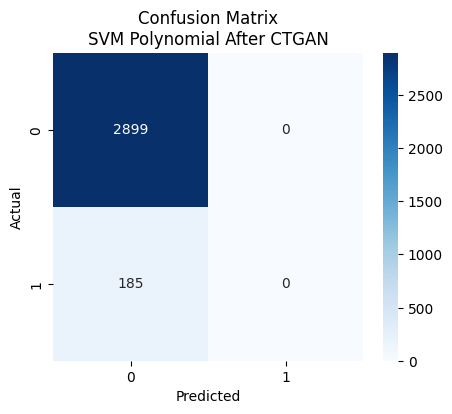

In [58]:
# SVM polynomial setelah CTGAN

results.append(
    evaluate_model(
        "SVM Polynomial After CTGAN",

        y_train_aug,
        y_train_pred_poly_aug,

        y_test,
        y_test_pred_poly_aug
    )
)


SVM RBF After CTGAN

TRAIN
Accuracy : 0.9681841696844283
Precision: 1.0
Recall   : 0.9363683393688567
F1-Score : 0.9671386588298156

TEST
Accuracy : 0.9400129701686122
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.05998702983138781

Confusion Matrix
[[2899    0]
 [ 185    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

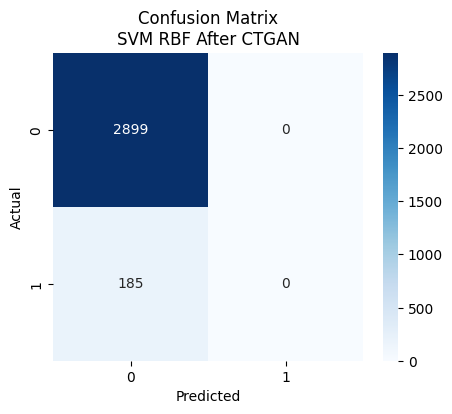

In [59]:
# SVM RBF setelah CTGAN

results.append(
    evaluate_model(
        "SVM RBF After CTGAN",

        y_train_aug,
        y_train_pred_rbf_aug,

        y_test,
        y_test_pred_rbf_aug
    )
)

In [60]:
# Dataframe hasil

results_df = pd.DataFrame(results)

results_df

,Model,Train Accuracy,Train Precision,Train Recall,Train F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score,ROC-AUC,PR-AUC
0,SVM Linear Before CTGAN,0.940337,0.750000,0.004065,0.008086,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
1,SVM Polynomial Before CTGAN,0.953064,1.000000,0.215447,0.354515,0.938392,0.307692,0.021622,0.040404,0.509259,0.065343
2,SVM RBF Before CTGAN,0.942121,1.000000,0.032520,0.062992,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
3,SVM Linear After CTGAN,0.968270,0.999908,0.936627,0.967234,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
4,SVM Polynomial After CTGAN,0.969564,1.000000,0.939127,0.968608,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
5,SVM RBF After CTGAN,0.968184,1.000000,0.936368,0.967139,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987


In [61]:
# Urutan model terbaik berdasarkan F1-score

results_df = results_df.sort_values(
    by='Test F1-Score',
    ascending=False
)

results_df

,Model,Train Accuracy,Train Precision,Train Recall,Train F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score,ROC-AUC,PR-AUC
1,SVM Polynomial Before CTGAN,0.953064,1.000000,0.215447,0.354515,0.938392,0.307692,0.021622,0.040404,0.509259,0.065343
0,SVM Linear Before CTGAN,0.940337,0.750000,0.004065,0.008086,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
2,SVM RBF Before CTGAN,0.942121,1.000000,0.032520,0.062992,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
3,SVM Linear After CTGAN,0.968270,0.999908,0.936627,0.967234,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
4,SVM Polynomial After CTGAN,0.969564,1.000000,0.939127,0.968608,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987
5,SVM RBF After CTGAN,0.968184,1.000000,0.936368,0.967139,0.940013,0.000000,0.000000,0.000000,0.500000,0.059987


## **Waktu Komputasi**

In [62]:
import time

# SVM linear sebelum CTGAN

start_time = time.time()

svm_linear.fit(
    X_train_scaled,
    y_train
)

end_time = time.time()

linear_before_time = end_time - start_time

# SVM polynomial sebelum CTGAN
start_time = time.time()

svm_poly.fit(
    X_train_scaled,
    y_train
)

end_time = time.time()

poly_before_time = end_time - start_time

# SVM RBF sebelum CTGAN

start_time = time.time()

svm_rbf.fit(
    X_train_scaled,
    y_train
)

end_time = time.time()

rbf_before_time = end_time - start_time

# SVM linear setelah CTGAN

start_time = time.time()

svm_linear_aug.fit(
    X_train_aug_scaled,
    y_train_aug
)

end_time = time.time()

linear_after_time = end_time - start_time

# SVM polynomial setelah CTGAN
start_time = time.time()

svm_poly_aug.fit(
    X_train_aug_scaled,
    y_train_aug
)

end_time = time.time()

poly_after_time = end_time - start_time

# SVM RBF setelah CTGAN
start_time = time.time()

svm_rbf_aug.fit(
    X_train_aug_scaled,
    y_train_aug
)

end_time = time.time()

rbf_after_time = end_time - start_time

# Waktu komputasi

computation_time = pd.DataFrame({

    'Model': [
        'SVM Linear Before CTGAN',
        'SVM Polynomial Before CTGAN',
        'SVM RBF Before CTGAN',
        'SVM Linear After CTGAN',
        'SVM Polynomial After CTGAN',
        'SVM RBF After CTGAN'
    ],

    'Waktu Komputasi (detik)': [
        linear_before_time,
        poly_before_time,
        rbf_before_time,

        linear_after_time,
        poly_after_time,
        rbf_after_time
    ]
})

computation_time

,Model,Waktu Komputasi (detik)
0,SVM Linear Before CTGAN,16.301730
1,SVM Polynomial Before CTGAN,5.885089
2,SVM RBF Before CTGAN,5.900047
3,SVM Linear After CTGAN,80.711085
4,SVM Polynomial After CTGAN,14.889219
5,SVM RBF After CTGAN,15.210665
